In [11]:


import numpy as np
import pandas as pd
from obspy import read
import os
import numpy as np
import pandas as pd
from obspy import read
from obspy.core.trace import Trace
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

FC    = 5.0
BANDS = np.array([3., 4., 5., 6., 7., 8., 9.])

STARTTIME_TOL_S = 2.0

SCENARIOS = [
    dict( LOWER_TOL=0.75, MIN_POST=2, K_NEG=1, K_PRE_POS=1),
]

# -------------------------
# EXCEL LOADING / NORMALIZATION
# -------------------------
def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(
            f"Missing columns in sheet '{sheet}': {missing}\n"
            f"Available: {list(d.columns)}"
        )

    d["station"] = d["station"].astype(str)
    d["fc_hz"]   = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    d["starttime_dt"]  = pd.to_datetime(d["starttime"],  errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()

    # Excel notion of event (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # dt_rel relative to FC per event (using FC band's t0_dt_mean as reference)
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands  = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


# -------------------------
# MATCH MSEED EVENTS TO EXCEL EVENTS
# -------------------------
def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")

        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]

            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


# -------------------------
# MAIN
# -------------------------
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)
t0_mat = (
    df_long.pivot_table(
        index="event",
        columns="band",
        values="t0_dt_mean_dt",
        aggfunc="first"
    )
    .reindex(columns=BANDS)
    .sort_index()
)

print(t0_mat.head())
# event-level distance
dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)

# event-level "best time": FC-band t0_dt_mean_dt
t0best_map = (
    df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
    .dropna()
    .drop_duplicates(subset=["event"])
    .set_index("event")["t0_dt_mean_dt"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

for cfg in SCENARIOS:
    LOWER_TOL = float(cfg["LOWER_TOL"])
    MIN_POST  = int(cfg["MIN_POST"])
    K_NEG     = int(cfg["K_NEG"])
    K_PRE_POS = int(cfg["K_PRE_POS"])

    keep_mask = select_events(
        dt_mat=dt_mat, FC=FC, BANDS=BANDS,
        MIN_POST=MIN_POST, K_NEG=K_NEG, K_PRE_POS=K_PRE_POS,
        LOWER_TOL=LOWER_TOL
    )

    kept_events = keep_mask.index[keep_mask].tolist()
    n_kept, n_tot = int(keep_mask.sum()), int(len(keep_mask))
    print(f" Kept by dt_rel criteria: {n_kept}/{n_tot}")

    # also require a MiniSEED match
    kept_events = [ev for ev in kept_events if ev in event_to_trace]
    print(f"Kept with MiniSEED match: {len(kept_events)}/{n_kept}")

    if not kept_events:
        print(f" No events after MiniSEED matching.")
        continue

    # Build and print table
    rows = []
    for ev in kept_events:
        rows.append(dict(
            event=ev,  # <-- add this back
            time_utc=t0best_map.get(ev, pd.NaT),
            station=ev.split("__", 1)[-1],
            epi_deg=dist_map.get(ev, np.nan),
        ))

    out_df = pd.DataFrame(rows)
    out_df["epi_deg"] = pd.to_numeric(out_df["epi_deg"], errors="coerce")
    out_df = out_df.sort_values(["epi_deg", "time_utc"], na_position="last").reset_index(drop=True)

    # Print all selected events (or use .head(20) if too long)
    print(f"LOWER_TOL={LOWER_TOL}, MIN_POST={MIN_POST}, K_NEG={K_NEG}, K_PRE_POS={K_PRE_POS} \n Selected events (time_utc, station, epi_deg):")
    print(out_df.to_string(index=False))


band                                                               3.0  \
event                                                                    
1971-04-17 06:51:55.001000+00:00__S14 1971-04-17 07:04:57.803000+00:00   
1971-05-20 17:16:10.013000+00:00__S14 1971-05-20 17:28:58.621000+00:00   
1972-01-02 22:20:40.002000+00:00__S15                              NaT   
1972-12-06 22:59:00.004000+00:00__S15 1972-12-06 23:10:40.242000+00:00   
1972-12-06 22:59:00.008000+00:00__S14 1972-12-06 23:12:35.496000+00:00   

band                                                               4.0  \
event                                                                    
1971-04-17 06:51:55.001000+00:00__S14 1971-04-17 07:04:57.620000+00:00   
1971-05-20 17:16:10.013000+00:00__S14                              NaT   
1972-01-02 22:20:40.002000+00:00__S15 1972-01-02 22:33:18.748000+00:00   
1972-12-06 22:59:00.004000+00:00__S15 1972-12-06 23:10:45.132000+00:00   
1972-12-06 22:59:00.008000+00:00__S14

In [14]:
def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = [
        "starttime", "station", "fc_hz", "t0_dt_mean",
        "lognonne_P_utc", "nakamura_P_utc", "margarit_P_utc"
    ]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(
            f"Missing columns in sheet '{sheet}': {missing}\n"
            f"Available: {list(d.columns)}"
        )

    # types / parsing
    d["station"] = d["station"].astype(str)
    d["fc_hz"]   = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    d["starttime_dt"]  = pd.to_datetime(d["starttime"],  errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    d["lognonne_P_dt"] = pd.to_datetime(d["lognonne_P_utc"], errors="coerce", utc=True)
    d["nakamura_P_dt"] = pd.to_datetime(d["nakamura_P_utc"], errors="coerce", utc=True)
    d["margarit_P_dt"] = pd.to_datetime(d["margarit_P_utc"], errors="coerce", utc=True)

    # distance
    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    # keep only requested bands
    d = d[d["fc_hz"].isin(BANDS)].copy()

    # event key (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # FC reference t0 per event
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")

    # dt_rel
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    # minimal validity
    d = d[
        d["starttime_dt"].notna() &
        d["t0_dt_mean_dt"].notna()
    ].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "t0_dt_mean_dt",
        "lognonne_P_dt", "nakamura_P_dt", "margarit_P_dt"
    ]].rename(columns={"fc_hz": "band"})


In [16]:
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)

t0_mat = (
    df_long.pivot_table(index="event", columns="band", values="t0_dt_mean_dt", aggfunc="first")
    .reindex(columns=BANDS)
    .sort_index()
)

ref_picks = df_long.groupby("event", as_index=True).agg(
    lognonne_P_dt=("lognonne_P_dt", "min"),
    nakamura_P_dt=("nakamura_P_dt", "min"),
    margarit_P_dt=("margarit_P_dt", "min"),
).sort_index()


In [68]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm
import pandas as pd

plt.rcParams.update({'font.family': 'Helvetica Neue', 'font.size': 16})

def plot_band_histograms_vs_reference(t0_mat, ref_series, *, BANDS, ref_label, bin_width_s=5.0, events=None):
    if events is None:
        events = t0_mat.index.intersection(ref_series.index)
    else:
        events = pd.Index(events).intersection(t0_mat.index).intersection(ref_series.index)

    deltas = {}
    all_dt = []

    for b in BANDS:
        ok = t0_mat.loc[events, b].notna() & ref_series.loc[events].notna()
        dt = (t0_mat.loc[events, b][ok] - ref_series.loc[events][ok]).dt.total_seconds().to_numpy(float)
        deltas[b] = dt
        if dt.size:
            all_dt.append(dt)

    if not all_dt:
        print(f"[{ref_label}] No valid deltas to plot (check missing picks / t0_dt_mean).")
        return

    all_concat = np.concatenate(all_dt)
    xmin = bin_width_s * math.floor(all_concat.min() / bin_width_s)
    xmax = bin_width_s * math.ceil(all_concat.max() / bin_width_s)
    if xmax == xmin:
        xmax = xmin + bin_width_s

    bins = np.arange(xmin, xmax + bin_width_s, bin_width_s)
    xticks = np.arange(xmin, xmax + bin_width_s, 2 * bin_width_s)

    fig, axes = plt.subplots(len(BANDS), 1, figsize=(10, 2.2 * len(BANDS)), sharex=True)
    axes = np.atleast_1d(axes)

    fig.suptitle(f"Δt = t0_dt_mean(band) − {ref_label}  (bin={bin_width_s:g}s)", y=0.995)

    for ax, b in zip(axes, BANDS):
        dt = deltas[b]
        ax.hist(dt, bins=bins)
        ax.set_ylabel(f"{b:g}± 0.5 Hz | N={dt.size}\nCounts")
        ax.set_xticks(xticks)
        ax.grid(True, axis="x", alpha=0.4)
        ax.grid(True, axis="y", alpha=0.3)
        ax.axvline(0, color="red", linestyle="--", alpha=0.7)

        # Gaussian envelope (scaled to counts)
        if dt.size > 1:
            mu = dt.mean()
            sigma = dt.std(ddof=1)
            if sigma > 0:
                x = np.linspace(bins[0], bins[-1], 600)
                y = norm.pdf(x, mu, sigma) * dt.size * bin_width_s
                ax.plot(x, y, linewidth=2.2)

    axes[-1].set_xlabel(f"My t0_est - {ref_label} (s)")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


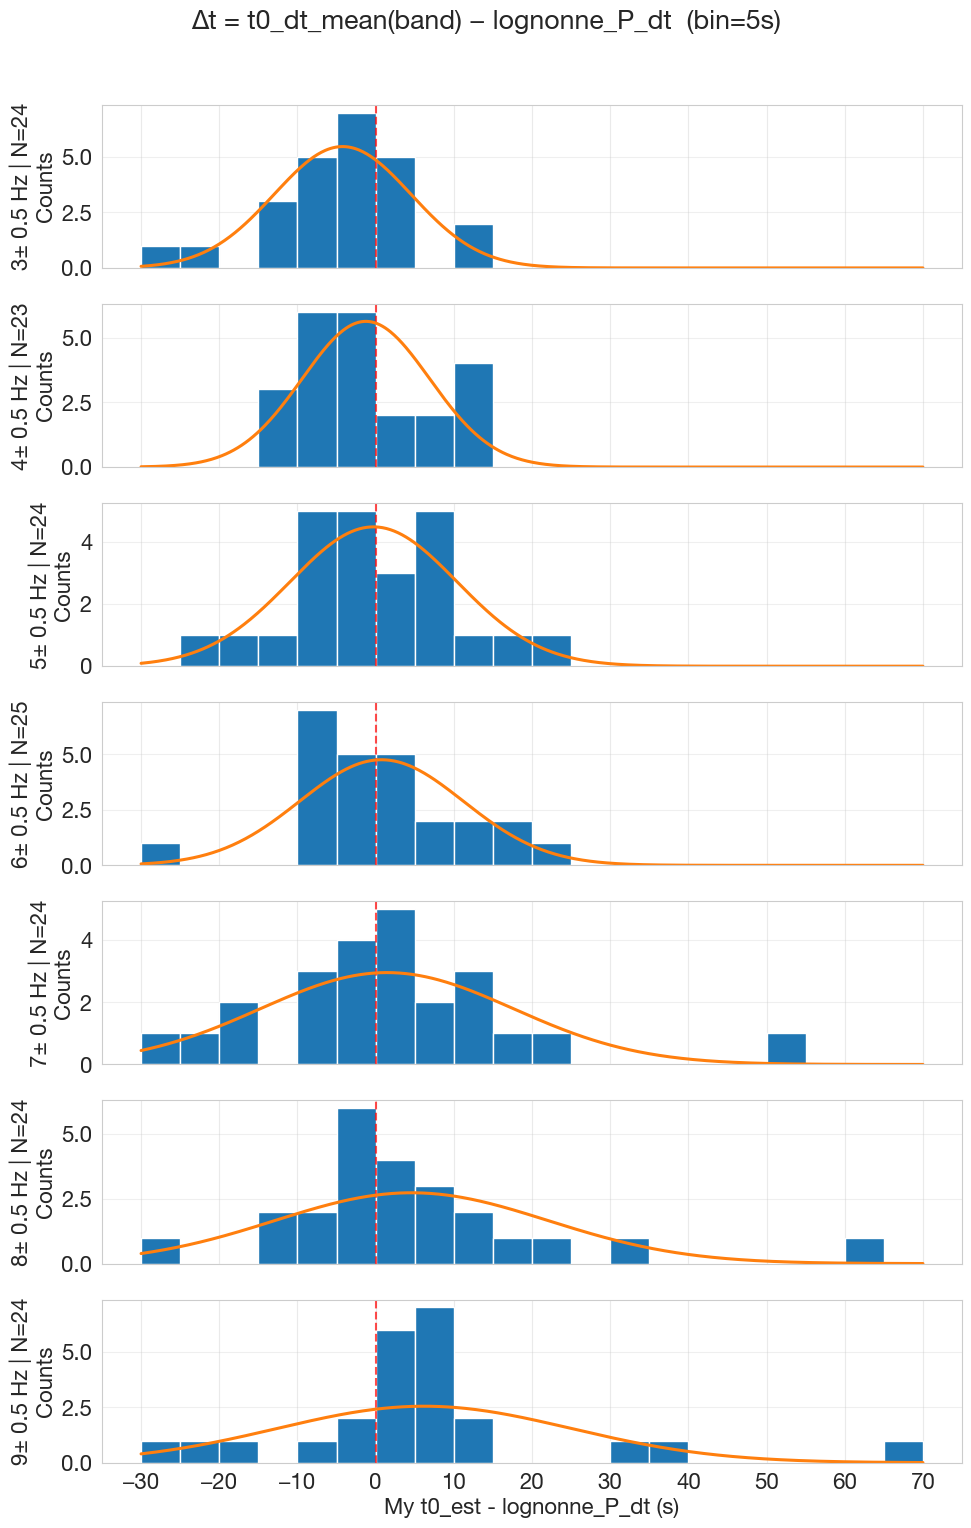

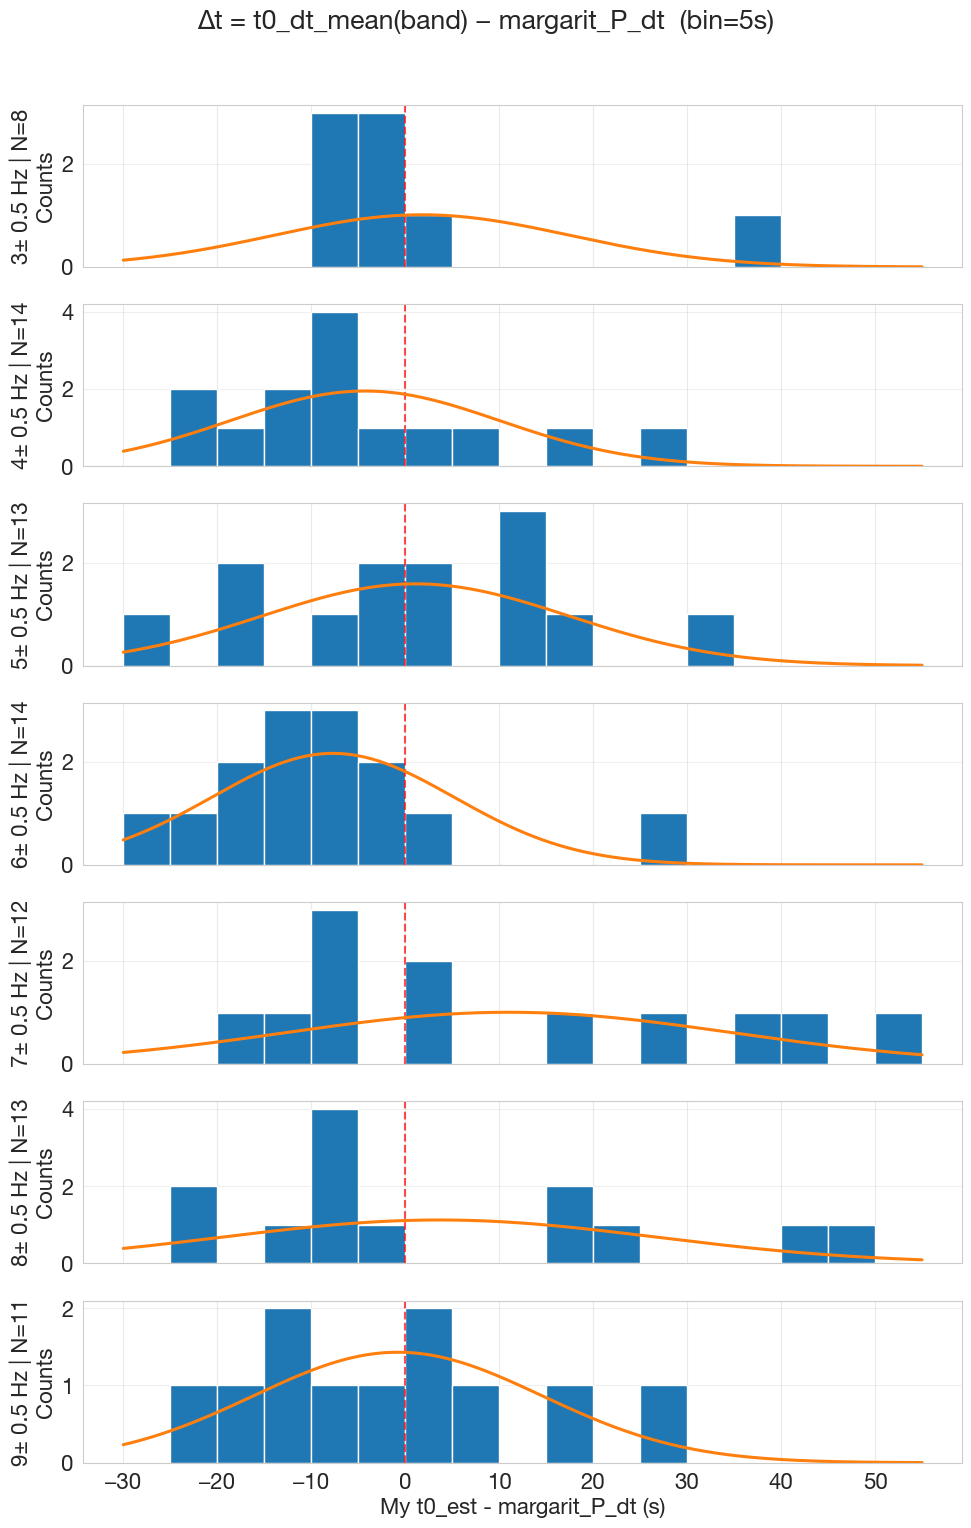

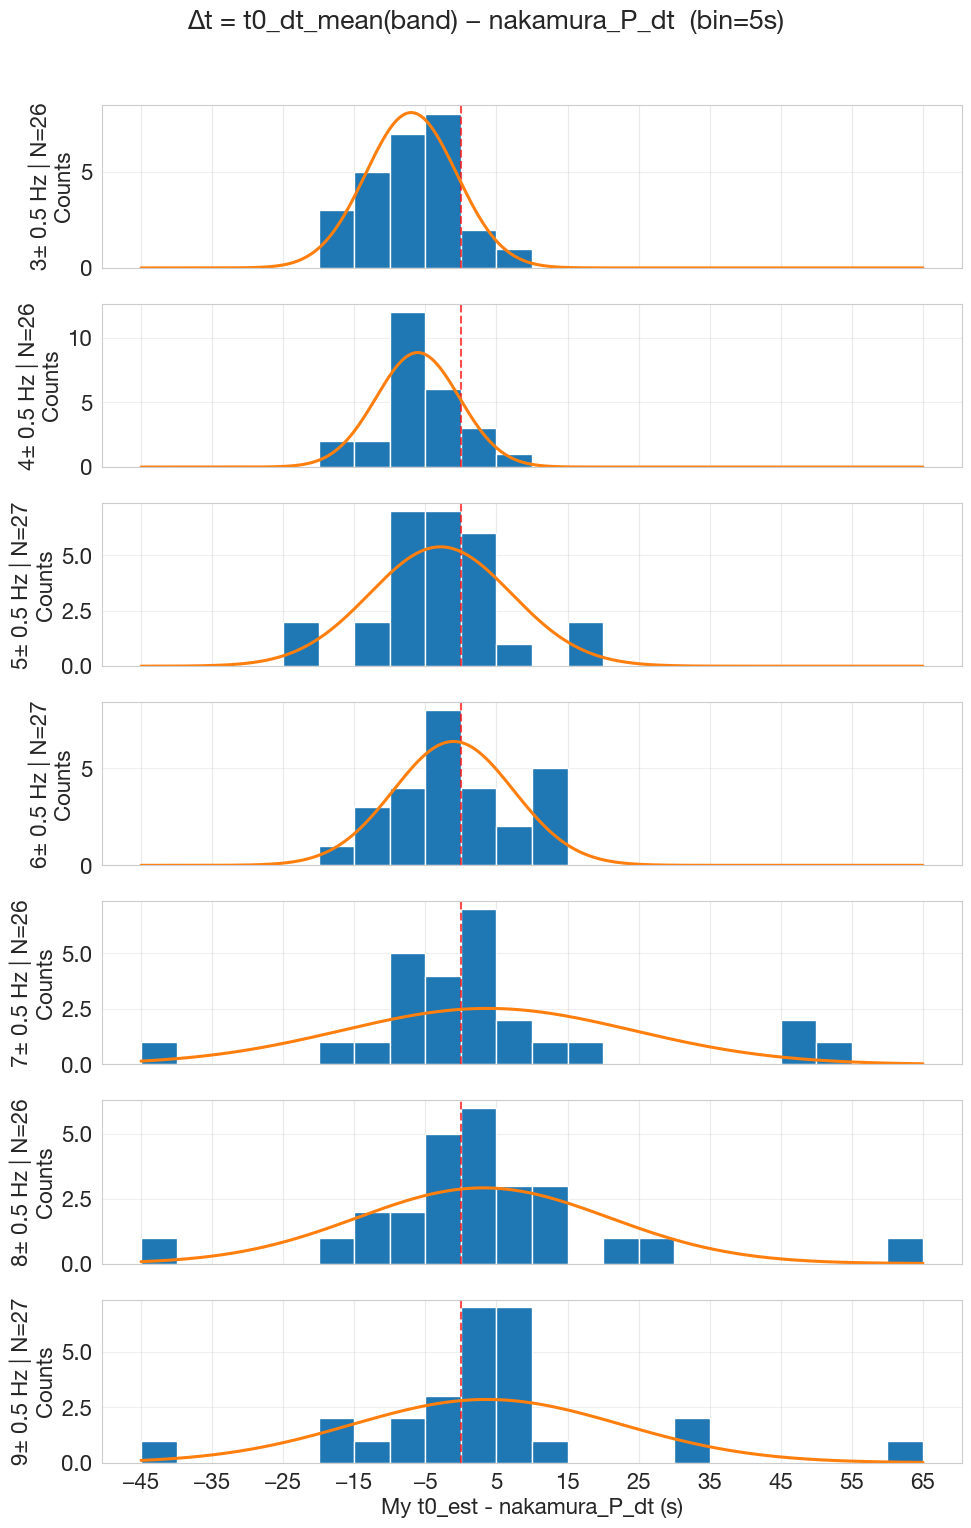

In [72]:
plot_band_histograms_vs_reference(
    t0_mat=t0_mat,
    ref_series=ref_picks["lognonne_P_dt"], 
    BANDS=BANDS,
    ref_label="lognonne_P_dt",
    bin_width_s= 5
)         
plot_band_histograms_vs_reference(
    t0_mat=t0_mat,
    ref_series=ref_picks["margarit_P_dt"], 
    BANDS=BANDS,
    ref_label="margarit_P_dt",
    bin_width_s= 5
)
plot_band_histograms_vs_reference(
    t0_mat=t0_mat,
    ref_series=ref_picks["nakamura_P_dt"], 
    BANDS=BANDS,
    ref_label="nakamura_P_dt",
    bin_width_s= 5
)
